## Checking $\frac{df}{d\xi}$ estimate

Testing whether a simple estimate of $\frac{df}{d\xi} \approx \frac{\Delta f}{\Delta\psi}$ is equivalent to $\frac{\nabla\psi}{|\nabla\psi|}\cdot \nabla f$ in the simple case where $f = \psi(x,y) = ax + by$.

In [34]:
from matplotlib import pyplot as plt
import numpy as np
from contourpy import contour_generator
from scipy import interpolate

x,y = np.meshgrid(np.linspace(0,10,100),np.linspace(0,10,100))
a = 1
b = 1
f = a*x + b*y
n_contours = 20
f_levels = a*np.linspace(x[0,0],20,n_contours)

In [25]:
def gen_contour_array(xgrid, mugrid, psi_grid, psi_levels):

    cont_gen = contour_generator(mugrid, xgrid, psi_grid, quad_as_tri=True)
    lines_arr_0 = np.array(cont_gen.lines(psi_levels[0]))[0]
    contour_array = np.hstack((lines_arr_0,np.reshape(np.zeros(len(lines_arr_0)),(-1,1))))

    for index in range(1,len(psi_levels)):
        # check if cont_gen.lines() returns an empty array:
        if(len(cont_gen.lines(psi_levels[index])) == 0):
            continue
        else:
            lines = np.array(cont_gen.lines(psi_levels[index])[0])
            contour_array = np.append(contour_array, np.hstack((lines, np.reshape(index*np.ones(len(lines)), (-1,1)))), axis=0)

    # remove any contour coordinates below some limit xlim:
    # contour_array_output = contour_array[((contour_array[:,1] < 1.e-10))|(contour_array[:,1] > 1.e-3)]

    return contour_array

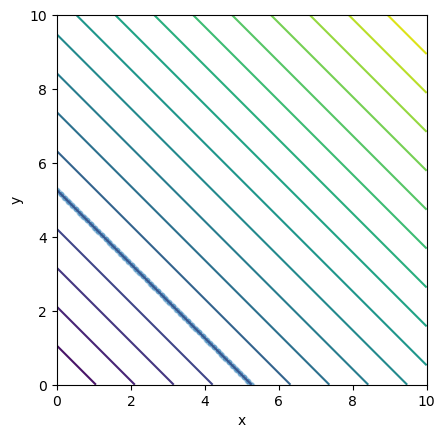

In [50]:
# generate contour array and select a particulatr contour
contour_array = gen_contour_array(x,y,f,f_levels)

gradx_grid, grady_grid = np.gradient(f,x[0,:],y[:,0],edge_order=2)

c = 5
x_c = contour_array[contour_array[:,2]==c][:,0]
y_c = contour_array[contour_array[:,2]==c][:,1]
xx = x[0,:]
yy = y[:,0]
itp_x = interpolate.RegularGridInterpolator((xx,yy),gradx_grid)
itp_y = interpolate.RegularGridInterpolator((xx,yy),grady_grid)
gradx_c = itp_x((x_c,y_c))
grady_c = itp_y((x_c,y_c))

grad_f_c = np.sqrt(gradx_c**2 + grady_c**2)

fig,ax = plt.subplots()
ax.contour(x,y,f,levels=f_levels)
ax.scatter(x_c,y_c, s=10,alpha = 0.2)
ax.set_aspect('equal', 'box')
ax.set(xlabel='x',ylabel='y')
plt.show()